## TC 5033
## Deep Learning
## Transformers

#### Activity 4: Implementing a Translator

- Objective

To understand the Transformer Architecture by Implementing a translator.

- Instructions

    This activity requires submission in teams. While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Follow the provided code. The code already implements a transformer from scratch as explained in one of [week's 9 videos](https://youtu.be/XefFj4rLHgU)

    Since the provided code already implements a simple translator, your job for this assignment is to understand it fully, and document it using pictures, figures, and markdown cells.  You should test your translator with at least 10 sentences. The dataset used for this task was obtained from [Tatoeba, a large dataset of sentences and translations](https://tatoeba.org/en/downloads).
  
- Evaluation Criteria

    - Code Readability and Comments
    - Traning a translator
    - Translating at least 10 sentences.

- Submission

Submit this Jupyter Notebook in canvas with your complete solution, ensuring your code is well-commented and includes Markdown cells that explain your design choices, results, and any challenges you encountered.



# Team 48

* Leonardo Daniel Rodriguez Vega - A01797465
* Rigoberto Bracamontes Salazar - A01134473
* Mayra Judith Vargas Rivero - A01797375
* Oliver Jordy Perez Escamilla - A01797471

## Introduction

This activity aims to build an understanding of transformer architecture. Initially, transformers were designed for translation tasks; however, their use has expanded significantly, enabling their application in generative models such as ChatGPT.

Traditional approaches using recurrent neural networks (RNNs) or long short-term memory (LSTM) models present challenges in translation tasks, particularly due to the vanishing gradient problem, which can reduce their effectiveness. As a result, transformers have become more popular, leveraging encoder and decoder layers to improve performance in these applications.

## Transformer Architecture Overview

The Transformer, introduced in ["Attention Is All You Need" (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762), revolutionized sequence-to-sequence modeling by replacing recurrence entirely with **self-attention** mechanisms. Unlike RNNs/LSTMs, which process tokens sequentially, the Transformer processes all tokens in parallel, leading to faster training and better capture of long-range dependencies.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8f/The-Transformer-model-architecture.png" width="350" alt="Transformer Architecture"/>

*Figure: The Transformer model architecture (Vaswani et al., 2017). The encoder (left) processes the source sentence; the decoder (right) generates the target sentence autoregressively.*

### Key Components

| Component | Purpose |
|-----------|---------|
| **Positional Embedding** | Injects position information since self-attention is position-agnostic |
| **Multi-Head Attention** | Allows the model to attend to different representation subspaces simultaneously |
| **Feed-Forward Network** | Applies non-linear transformations independently to each position |
| **Layer Normalization** | Stabilizes training by normalizing activations |
| **Residual Connections** | Facilitates gradient flow through deep networks |
| **Masking** | Padding mask (ignores `<pad>` tokens) and causal mask (prevents decoder from looking ahead) |

### Positional Encoding

Since the Transformer has no recurrence, sinusoidal functions at different frequencies inject position information:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \quad\quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Scaling by $\sqrt{d_k}$ prevents dot products from becoming too large, which would push softmax into regions with very small gradients.

### Multi-Head Attention

Instead of computing a single attention, the model uses $h=8$ parallel heads, each operating on a $d_k = d_{model}/h = 64$ dimensional subspace:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \cdot W^O$$

### Hyperparameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| `d_model` | 512 | Embedding dimension |
| `num_heads` | 8 | Number of attention heads |
| `d_ff` | 2048 | Feed-forward hidden dimension |
| `num_layers` | 6 | Number of encoder/decoder layers |
| `dropout` | 0.1 | Dropout rate |
| `MAX_SEQ_LEN` | 128 | Maximum sequence length |

#### Script to convert csv to text file

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import numpy as np
import re
import pandas as pd

torch.manual_seed(23)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DIR = '/content/drive/MyDrive/MNA/Advanced Machine Learning Methods/A4/Final'

Mounted at /content/drive


In [ ]:
#This script requires to convert the TSV file to CSV
# easiest way is to open it in Calc or excel and save as csv
PATH = DIR + '/eng-spa2026.tsv'
df = pd.read_csv(PATH, sep='\t',on_bad_lines='skip')

In [ ]:
eng_spa_cols = df.iloc[:, [1, 3]]
eng_spa_cols['length'] = eng_spa_cols.iloc[:, 0].str.len()
eng_spa_cols = eng_spa_cols.sort_values(by='length')
eng_spa_cols = eng_spa_cols.drop(columns=['length'])

output_file_path = DIR + '/eng-spa.txt'
eng_spa_cols.to_csv(output_file_path, sep='\t', index=False, header=False)

/tmp/ipykernel_13282/2464699670.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eng_spa_cols['length'] = eng_spa_cols.iloc[:, 0].str.len()


## Transformer - Attention is all you need

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')  # Use Apple Silicon GPU!
else:
    device = torch.device('cpu')

print(device)

cuda


In [ ]:
MAX_SEQ_LEN = 128

### **Positional Encoding**


It is a layer that allows us to generate an embedding vector thru trigonometric functions that normalize the values between -1 and 1 to provide stability to the model. This layer is applied because our model applies attention transformations in parallel, and in this way, we maintain the position of the token within the vector.

For even positions
$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$

For odd positions:
$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$

Where:

$pos$: position of the token

$i$: index of our embeddings vector

$d_{\text{model}}$: total dimension of the model (the paper mentions a size of 512)

$10000$: Constant to define the period

In [ ]:
#we create our class to define our positional encoding layer
class PositionalEmbedding(nn.Module):
    """
    Sinusoidal Positional Encoding from "Attention Is All You Need".
    Since Transformers have no recurrence, positional encodings are added to
    input embeddings to provide information about token position in the sequence.

    Uses fixed sinusoidal functions:
      PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
      PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_seq_len = MAX_SEQ_LEN):
        super().__init__()
        #we initialize our matrix with zeros
        self.pos_embed_matrix = torch.zeros(max_seq_len, d_model, device=device)

        #we initialize our vector with a sequence from 0 to max_seq_len
        token_pos = torch.arange(0, max_seq_len, dtype = torch.float).unsqueeze(1)

        #we calculate the denominator for the calculation of our positional
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0)/d_model))

        #we perform the sine calculation of even numbers
        self.pos_embed_matrix[:, 0::2] = torch.sin(token_pos * div_term)

        #we perform the sine calculation of the odd numbers
        self.pos_embed_matrix[:, 1::2] = torch.cos(token_pos * div_term)

        #we made an adjustment to the dimensions so that they fit our calculations
        self.pos_embed_matrix = self.pos_embed_matrix.unsqueeze(0).transpose(0,1)

    def forward(self, x):
        #adds our previously calculated matrix in our constructor with our embeddings
        return x + self.pos_embed_matrix[:x.size(0), :]

### **Multihead attention**



**Scaled Dot-Product Attention**

The input consists of queries and keys of dimension $d_{\text{k}}$ , and values of dimension $d_{\text{v}}$. We compute the dot products of the query with all keys, divide each by $\sqrt{d_{\text{k}}}$, and apply a softmax function to obtain the weights on the values

**Attention**

An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors.

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

Where:

Query ($Q$): It is the word vector

Key ($K$): It is the vector of the word identifiers

Value ($V$): It is the vector that indicates the value of the words

Softmax: normalization function applied in our layer


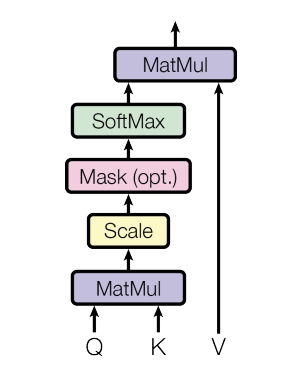



**MultiHead Attention**

Instead of performing a single attention function with $d_{\text{model}}-dimensional$  keys, values and queries, we found it beneficial to linearly project the queries, keys and values h times with different, learned linear projections to $d_{\text{k}}$, $d_{\text{k}}$ and $d_{\text{v}}$ dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding $d_{\text{v}}-dimensional$ output values. These are concatenated and once again projected, resulting in the final values


$\text{MultiHead}(Q, K, V) = \text{Concat}(head_1, \dots, head_h)W^O$

$head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

Where:

$W_i^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$: This matrix takes a vector of size $d_{\text{model}}$ and projects it into a space of size $d_k$.

$W_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$: The same goes for the Keys. It is vital that $Q$ and $K$ end up with the same dimension ($d_k$).

$W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$: The Values can have a different dimension ($d_v$), although in general, it is almost always $d_k = d_v$.


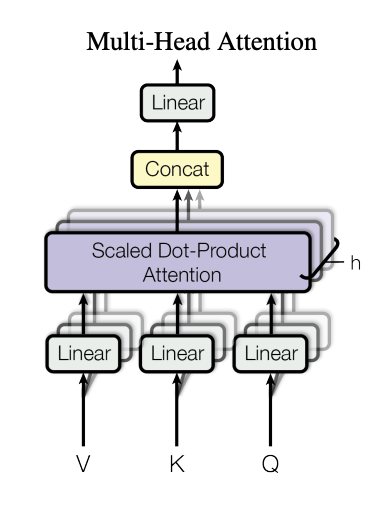










In [ ]:
#we create our class to perform the calculations of the multihead attention layer
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention mechanism.
    Instead of a single attention function, Q, K, and V are linearly projected
    h times with different learned projections. Attention is applied in parallel
    across all heads, and the results are concatenated and projected:

      MultiHead(Q,K,V) = Concat(head_1,...,head_h) * W_o
      where head_i = Attention(Q*W_q_i, K*W_k_i, V*W_v_i)
    """
    def __init__(self, d_model = 512, num_heads = 8):
        super().__init__()

        #we perform the validation of the dimensions of our embedding to avoid inconsistencies in our model
        assert d_model % num_heads == 0, 'Embedding size not compatible with num heads'

        #based on the architecture, we performed the calculation for d_v
        self.d_v = d_model // num_heads

        #based on our architecture, we can see that the value of d_k=d_v
        self.d_k = self.d_v

        #we initialize the value of num heads
        self.num_heads = num_heads

        #we create our W matrices which are linear layers (the W matrices represent the synaptic weights
        #that are used to transform our input X)
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, Q, K, V, mask = None):
        #we persist the value of our minibatch
        batch_size = Q.size(0)

        '''
        Q, K, V -> [batch_size, seq_len, num_heads*d_k]
        after transpose Q, K, V -> [batch_size, num_heads, seq_len, d_k]
        '''
        #we calculate our Q,K,V matrices (inputs to our encoder)
        #where we will have dimensions for num_heads and another for the elements for each head
        #the transpose is performed because the multiplication with self-attention is done afterward
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )

        #we obtain the value matrix and the calculation of our attention
        weighted_values, attention = self.scale_dot_product(Q, K, V, mask)

        #we perform the transpose to return the heads to their original position
        #we also apply the contiguous() method so that the data is properly
        # ordered for in-memory processing
        weighted_values = weighted_values.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads*self.d_k)

        #we apply a linear layer to integrate the learned patterns
        weighted_values = self.W_o(weighted_values)

        #we return our value matrix and the calculation of our attention
        return weighted_values, attention


    def scale_dot_product(self, Q, K, V, mask = None):
        #we calculate our scores based on our equation defined in our architecture
        #transpose K to perform the appropriate multiplication of our matrices
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        #we check if a mask exists
        if mask is not None:
            #we calculate the scores, to obtain a probability of zero when softmax is performed
            scores = scores.masked_fill(mask == 0, -1e9)

        #we perform the attention calculation with a softmax
        attention = F.softmax(scores, dim = -1)

        #we calculate our attention matrix with V (values)
        weighted_values = torch.matmul(attention, V)

        #we return the values of our weighted_values matrix and the attention value
        return weighted_values, attention

### **Position-wise Feed-Forward Networks**

Each of the layers in our encoder and decoder contains a fully connected feed-forward network, which is applied to each position separately and identically. This consists of two linear transformations with a ReLU activation in between.

$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$

The objective of our FFN layer is to process the information of each word so that its meaning can be mathematically represented.



In [ ]:
#we created our class for the calculation of our feed forward layer
class PositionFeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network: FFN(x) = ReLU(x*W1 + b1)*W2 + b2
    Applied independently to each position. Expands to d_ff (2048)
    then projects back to d_model (512).
    """
    def __init__(self, d_model, d_ff):
        super().__init__()
        #we define our first linear layer with an input dimension of d_model
        #and an output dimension of d_ff
        self.linear1 = nn.Linear(d_model, d_ff)

        #we define the second linear layer with an input dimension of d_ff
        #and an output dimension d_model, this to return to the original dimensions
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        #we perform the softmax calculation on our first linear layer
        #which we then pass thru our second linear layer to return to the original dimensions
        return self.linear2(F.relu(self.linear1(x)))


### **Encoder**

An encoder is one of the layers of the transformer, whose main objective is to analyze the sequence of words to generate a mathematical representation of the semantics of each word.

The paper indicates that its architecture is composed as follows:

The encoder is composed of a stack of N = 6 identical layers. Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position wise fully connected feed-forward network.


In [ ]:
#we create the class that will allow us to generate the operations that contain the sublayers of the encoder
class EncoderSubLayer(nn.Module):
    """
    Single encoder layer: Self-Attention -> Add & Norm -> FFN -> Add & Norm.
    Each sub-layer uses a residual connection followed by layer normalization:
      output = LayerNorm(x + Sublayer(x))
    """
    def __init__(self, d_model, num_heads, d_ff, dropout = 0.1):
        super().__init__()
        #we initialize our multihead attention component
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        #we initialize our feed forward component
        self.ffn = PositionFeedForward(d_model, d_ff)

        #we initialize our normalization layers (implementing LayerNorm from PyTorch)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        #dropout is applied to help us avoid Overfitting in our model
        self.droupout1 = nn.Dropout(dropout)
        self.droupout2 = nn.Dropout(dropout)

    def forward(self, x, mask = None):
        #the calculation of our attention score is performed with the input parameters x
        attention_score, _ = self.self_attn(x, x, x, mask)

        #we add our original values to our dropout
        x = x + self.droupout1(attention_score)

        #we normalize our data
        x = self.norm1(x)

        #we add our original values to our dropout from the result of our FFN (feed forward)
        x = x + self.droupout2(self.ffn(x))

        #we normalize our values and return them
        return self.norm2(x)


In [ ]:
#we create our encoder class with which we will connect the sublayers by applying the steps
#that are defined in our architecture
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        #we define our layers
        self.layers = nn.ModuleList([EncoderSubLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        #we define our normalization (implementing LayerNorm from pytorch)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        #we traverse each layer applying the steps previously defined in the EncoderSubLayer class
        for layer in self.layers:
            x = layer(x, mask)

        #to our output, we apply normalization to provide greater stability in our model
        return self.norm(x)


### **Decoder**

The decoder is the layer that allows us to process the information of the words, to provide an output sequence, that is, the next word or words, obtaining the context of each one of them.

The decoder is also composed of a stack of N = 6 identical layers. In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization.



In [ ]:
#let's create our class to define the steps of our decoder sublayers
class DecoderSubLayer(nn.Module):
    """
    Single decoder layer with three sub-layers:
      1. Masked Self-Attention (prevents attending to future tokens)
      2. Cross-Attention (attends to encoder output: Q=decoder, K=V=encoder)
      3. Position-wise Feed-Forward Network
    Each with residual connection + layer normalization.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        #we initialize our self attention (with the multihead attention class)
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        #we define our cross attention (with the multihead attention class)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionFeedForward(d_model, d_ff)

        #we initialize our normalizations
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        #we initialize our dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, target_mask=None, encoder_mask=None):
        #we calculate our attention score with its respective mask
        attention_score, _ = self.self_attn(x, x, x, target_mask)

        #we apply a sum of our original values and apply a dropout with our attention score
        x = x + self.dropout1(attention_score)

        #we performed our first normalization
        x = self.norm1(x)

        #we calculate our encoder attention score
        encoder_attn, _ = self.cross_attn(x, encoder_output, encoder_output, encoder_mask)

        #we perform the sum of our x values to our second dropout with the encoder attention score value
        x = x + self.dropout2(encoder_attn)

        #we conducted our second normalization
        x = self.norm2(x)

        #we carry out our feed forward
        ff_output = self.feed_forward(x)

        #we perform the sum of our x values to the dropout with the feed forward value
        x = x + self.dropout3(ff_output)

        #we performed our final normalization and returned our values
        return self.norm3(x)


In [ ]:
#we create our class for the decoder, with which we will carry out the steps of each sublayer connecting them to each other
class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        #we define our list of layers
        self.layers = nn.ModuleList([DecoderSubLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        #we define data normalization
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, target_mask, encoder_mask):
        #we go thru each layer, where each step is applied to perform the transformations
        for layer in self.layers:
            x = layer(x, encoder_output, target_mask, encoder_mask)

        #we performed data normalization and returned it
        return self.norm(x)

### The Complete Transformer

The `Transformer` class ties together the encoder and decoder with their respective embedding layers and a final linear projection:

**Forward pass pipeline:**
1. **Masking**: Generate a padding mask for the source and a combined padding + causal mask for the target
2. **Source embedding**: Token embedding scaled by $\sqrt{d_{model}}$ + positional encoding
3. **Encoder**: Process the source through N=6 encoder layers
4. **Target embedding**: Same scaling and positional encoding for the target
5. **Decoder**: Process the target through N=6 decoder layers, using cross-attention to the encoder output
6. **Output projection**: Linear layer maps decoder output to target vocabulary logits

**Masking explained:**
- **Source (padding) mask**: A boolean tensor that is `True` for real tokens and `False` for `<pad>` positions, preventing attention to padding
- **Target (causal) mask**: Combines the padding mask with a lower-triangular matrix, ensuring that position $i$ can only attend to positions $\leq i$ (autoregressive property)


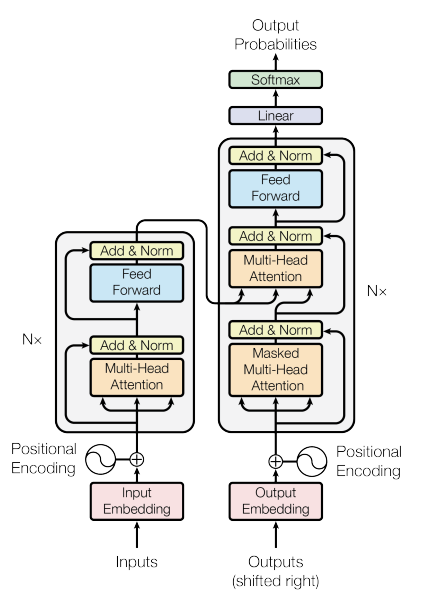


In [ ]:
#We create our transformer class, which will allow us to connect each layer and its respective sublayers of the
#encoder and decoder for the main operation of our transformer
class Transformer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers,
                 input_vocab_size, target_vocab_size,
                 max_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        #Initialize our encoder embedding
        self.encoder_embedding = nn.Embedding(input_vocab_size, d_model)

        #Initialize our decoder embedding
        self.decoder_embedding = nn.Embedding(target_vocab_size, d_model)

        #Initialize our PositionalEmbedding
        self.pos_embedding = PositionalEmbedding(d_model, max_len)

        #Initialize our encoder
        self.encoder = Encoder(d_model, num_heads, d_ff, num_layers, dropout)

        #Initialize our decoder
        self.decoder = Decoder(d_model, num_heads, d_ff, num_layers, dropout)

        #Define our output layer as a linear layer
        self.output_layer = nn.Linear(d_model, target_vocab_size)

    def forward(self, source, target):
        # Generate padding mask for source and causal mask for target
        source_mask, target_mask = self.mask(source, target)

        # Encoder pipeline: embed -> scale by sqrt(d_model) -> add positional encoding -> encode
        source = self.encoder_embedding(source) * math.sqrt(self.encoder_embedding.embedding_dim)
        source = self.pos_embedding(source)
        encoder_output = self.encoder(source, source_mask)

        # Decoder pipeline: embed -> scale -> positional encoding -> decode with cross-attention
        target = self.decoder_embedding(target) * math.sqrt(self.decoder_embedding.embedding_dim)
        target = self.pos_embedding(target)
        output = self.decoder(target, encoder_output, target_mask, source_mask)

        # Project decoder output to target vocabulary logits
        return self.output_layer(output)



    def mask(self, source, target):
        # Padding mask: True where token is NOT padding (id != 0)
        source_mask = (source != 0).unsqueeze(1).unsqueeze(2)
        target_mask = (target != 0).unsqueeze(1).unsqueeze(2)
        # Causal (look-ahead) mask: lower triangular matrix prevents
        # attending to future positions during autoregressive decoding
        size = target.size(1)
        no_mask = torch.tril(torch.ones((1, size, size), device=device)).bool()
        # Combine padding mask with causal mask
        target_mask = target_mask & no_mask
        return source_mask, target_mask


#### Simple test

Next, we will conduct some simple tests of our previously created transformer.


In [ ]:
seq_len_source = 10
seq_len_target = 10
batch_size = 2
input_vocab_size = 50
target_vocab_size = 50

#we initialize with random values
source = torch.randint(1, input_vocab_size, (batch_size, seq_len_source))
target = torch.randint(1, target_vocab_size, (batch_size, seq_len_target))

In [ ]:
#we define the values of our architecture based on what is defined in our architecture
d_model = 512
num_heads = 8
d_ff = 2048
num_layers = 6

#we create our model (Transformer)
model = Transformer(
    d_model,
    num_heads,
    d_ff,
    num_layers,
    input_vocab_size,
    target_vocab_size,
    max_len=MAX_SEQ_LEN,
    dropout=0.1
)

#we indicate to use the GPU (if available)
model = model.to(device)
source = source.to(device)
target = target.to(device)

In [ ]:
#we run the model
output = model(source, target)

In [ ]:
#we validated our model with the expected values-> [batch, seq_len_target, target_vocab_size] i.e. [2, 10, 50]
print(f'ouput.shape {output.shape}')

ouput.shape torch.Size([2, 10, 50])


### Translator: English to Spanish

#### Data Pipeline

The dataset is a collection of English-Spanish sentence pairs from [Tatoeba](https://tatoeba.org/en/downloads), a community-contributed corpus of translated sentences. Each line in the file contains an English sentence and its Spanish translation, separated by a tab character.

**Preprocessing steps:**
1. **Lowercasing** and whitespace normalization
2. **Accent removal** (a, e, etc.) to reduce vocabulary size
3. **Non-alphabetic character removal** (numbers, punctuation stripped)
4. **Special tokens**: `<sos>` (start-of-sequence) and `<eos>` (end-of-sequence) are prepended/appended

**Vocabulary building:** Words are mapped to integer indices sorted by frequency (most common = lowest index), with `<pad>=0` and `<unk>=1` reserved.

**DataLoader:** Sequences are truncated to `MAX_SEQ_LEN=128` and padded to equal length within each batch using `<pad>` tokens. Batch size: 64, shuffled for training.

In [ ]:
PATH = DIR + '/eng-spa.txt'

In [ ]:
#we prepare our dataset where each line will contain a sentence in English and its respective translation into Spanish
with open(PATH, 'r', encoding='utf-8') as f:
    lines = f.readlines()

eng_spa_pairs = [line.strip().split('\t') for line in lines if '\t' in line]

In [ ]:
#we show 10 values
eng_spa_pairs[:10]

[['Hi.', 'Hola.'],
 ['Go.', 'Váyase.'],
 ['OK.', '¡Órale!'],
 ['Hi.', '¡Hola!'],
 ['Go.', 'Vaya.'],
 ['Hi!', '¡Hola!'],
 ['Go.', 'Ve.'],
 ['So?', '¿Entonces?'],
 ['So?', '¿Y qué?'],
 ['Ow!', '¡Ay!']]

In [ ]:
#we separate the sentences by language
eng_sentences = [pair[0] for pair in eng_spa_pairs]
spa_sentences = [pair[1] for pair in eng_spa_pairs]

In [ ]:
#we show 10 values from each list
print(eng_sentences[:10])
print(spa_sentences[:10])


['Hi.', 'Go.', 'OK.', 'Hi.', 'Go.', 'Hi!', 'Go.', 'So?', 'So?', 'Ow!']
['Hola.', 'Váyase.', '¡Órale!', '¡Hola!', 'Vaya.', '¡Hola!', 'Ve.', '¿Entonces?', '¿Y qué?', '¡Ay!']


In [ ]:
#we define a method for preprocessing our input sentences to avoid introducing noise into our model
def preprocess_sentence(sentence):
    #we convert to lowercase
    sentence = sentence.lower().strip()

    #we validate the blank spaces
    sentence = re.sub(r'[" "]+', " ", sentence)

    #for the vowels we clean them to vowels without accents
    sentence = re.sub(r"[á]+", "a", sentence)
    sentence = re.sub(r"[é]+", "e", sentence)
    sentence = re.sub(r"[í]+", "i", sentence)
    sentence = re.sub(r"[ó]+", "o", sentence)
    sentence = re.sub(r"[ú]+", "u", sentence)
    sentence = re.sub(r"[^a-z]+", " ", sentence)

    #we remove spaces at the beginning or end for our sentence
    sentence = sentence.strip()

    #we add sequence markers
    #<sos> Start of Sequence: indicates the beginning of a sentence
    #<eos> End of Sequence: indicates the end of a sentence
    sentence = '<sos> ' + sentence + ' <eos>'

    #we return our clean sentence ready to be processed by our model
    return sentence

In [ ]:
#test sentence
s1 = '¿Hola @ cómo estás? 123'

In [ ]:
#we validate our preprocessing method
print(s1)
print(preprocess_sentence(s1))

¿Hola @ cómo estás? 123
<sos> hola como estas <eos>


In [ ]:
#we apply preprocessing to our pairs of English and Spanish sentences
eng_sentences = [preprocess_sentence(sentence) for sentence in eng_sentences]
spa_sentences = [preprocess_sentence(sentence) for sentence in spa_sentences]

In [ ]:
#we validate with 10 values
spa_sentences[:10]

['<sos> hola <eos>',
 '<sos> vayase <eos>',
 '<sos> orale <eos>',
 '<sos> hola <eos>',
 '<sos> vaya <eos>',
 '<sos> hola <eos>',
 '<sos> ve <eos>',
 '<sos> entonces <eos>',
 '<sos> y que <eos>',
 '<sos> ay <eos>']

In [ ]:
#we create our method to build our vocabulary
def build_vocab(sentences):
    """
    Build word-to-index and index-to-word mappings from tokenized sentences.
    Words are sorted by frequency (most common first). Reserves index 0 for
    <pad> and index 1 for <unk> (unknown/out-of-vocabulary words).
    """
    #we separate our words contained in our sentence
    words = [word for sentence in sentences for word in sentence.split()]

    #we perform the word count contained in our sentence
    word_count = Counter(words)

    #we sort the words based on their frequency
    sorted_word_counts = sorted(word_count.items(), key=lambda x:x[1], reverse=True)

    #we assign indices to our obtained words
    word2idx = {word: idx for idx, (word, _) in enumerate(sorted_word_counts, 2)}

    #padding is added to regulate our dictionary
    word2idx['<pad>'] = 0

    #the unknown token is added, which is useful in case there are unknown words in our dictionary
    word2idx['<unk>'] = 1

    #we generate our vector to perform an index search and thus find a word
    idx2word = {idx: word for word, idx in word2idx.items()}

    #we return our vectors
    return word2idx, idx2word

In [ ]:
#we build our vocabularies with word-to-index and index-to-word vectors
eng_word2idx, eng_idx2word = build_vocab(eng_sentences)
spa_word2idx, spa_idx2word = build_vocab(spa_sentences)

#we get the dimensions
eng_vocab_size = len(eng_word2idx)
spa_vocab_size = len(spa_word2idx)

In [ ]:
#we show the dimensions of each vocabulary.
#it is important to remember that since they are from different languages, the dimensions may vary between them
print(eng_vocab_size, spa_vocab_size)

28403 48271


In [ ]:
#we create our class for managing our dataset
class EngSpaDataset(Dataset):
    """PyTorch Dataset that converts preprocessed sentence pairs into index tensors."""
    def __init__(self, eng_sentences, spa_sentences, eng_word2idx, spa_word2idx):
        #we initialize our vectors that contain our sentences
        self.eng_sentences = eng_sentences
        self.spa_sentences = spa_sentences

        #we initialize our vectors to obtain the indices of our words from our vocabularies
        self.eng_word2idx = eng_word2idx
        self.spa_word2idx = spa_word2idx


    def __len__(self):
        #we return the dimension of our vector eng_sentences
        return len(self.eng_sentences)

    def __getitem__(self, idx):
        #this method allows us to obtain our indices and convert them into PyTorch tensors
        eng_sentence = self.eng_sentences[idx]
        spa_sentence = self.spa_sentences[idx]

        # return tokens idxs
        eng_idxs = [self.eng_word2idx.get(word, self.eng_word2idx['<unk>']) for word in eng_sentence.split()]
        spa_idxs = [self.spa_word2idx.get(word, self.spa_word2idx['<unk>']) for word in spa_sentence.split()]

        #we return our tensors
        return torch.tensor(eng_idxs), torch.tensor(spa_idxs)

In [ ]:
#we create our collate function
def collate_fn(batch):
    """
    Custom collation: truncates sequences to MAX_SEQ_LEN and pads each batch
    to the length of the longest sequence using <pad>=0.
    """
    #we separate the sequences of English and Spanish respectively
    eng_batch, spa_batch = zip(*batch)

    #we ensure the sequences do not exceed the defined maximum
    eng_batch = [seq[:MAX_SEQ_LEN].clone().detach() for seq in eng_batch]
    spa_batch = [seq[:MAX_SEQ_LEN].clone().detach() for seq in spa_batch]

    #we perform padding on our batches of English and Spanish
    eng_batch = torch.nn.utils.rnn.pad_sequence(eng_batch, batch_first=True, padding_value=0)
    spa_batch = torch.nn.utils.rnn.pad_sequence(spa_batch, batch_first=True, padding_value=0)

    #we return our batches
    return eng_batch, spa_batch


### Training

The training loop uses **teacher forcing**: at each decoder time step, the ground-truth previous token is provided as input (rather than the model's own prediction). This enables efficient parallel computation of the loss across all positions.

**Key details:**
- **Loss function**: `CrossEntropyLoss(ignore_index=0)` — standard classification loss over the target vocabulary, ignoring `<pad>` tokens (index 0) so padding doesn't affect gradients
- **Target shifting**: The decoder input is `<sos> w1 w2 ... wN` and the expected output is `w1 w2 ... wN <eos>` (shifted by one position)
- **Optimizer**: Adam with learning rate 0.0001
- **Epochs**: 10 passes over the full dataset

In [ ]:
def train(model, dataloader, loss_function, optimiser, epochs):
    """
    Training loop using teacher forcing: the decoder receives the ground-truth
    previous token as input at each step (target_input), and is trained to predict
    the next token (target_output). This is standard for seq2seq training.
    """
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for i, (eng_batch, spa_batch) in enumerate(dataloader):
            eng_batch = eng_batch.to(device)
            spa_batch = spa_batch.to(device)
            # Teacher forcing: input is all tokens except last, output is all except first
            # e.g. input: <sos> w1 w2 w3 -> predict: w1 w2 w3 <eos>
            target_input = spa_batch[:, :-1]
            target_output = spa_batch[:, 1:].contiguous().view(-1)
            # Zero grads
            optimiser.zero_grad()
            # run model
            output = model(eng_batch, target_input)
            output = output.view(-1, output.size(-1))
            # loss\
            loss = loss_function(output, target_output)
            # gradient and update parameters
            loss.backward()
            optimiser.step()
            total_loss += loss.item()

        avg_loss = total_loss/len(dataloader)
        print(f'Epoch: {epoch}/{epochs}, Loss: {avg_loss:.4f}')



In [ ]:
#we define the size of our batch
BATCH_SIZE = 64

#we initialize our dataset
dataset = EngSpaDataset(eng_sentences, spa_sentences, eng_word2idx, spa_word2idx)

#we initialize our dataloader
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [ ]:
#we initialize our model (Transformer) by assigning the values defined in our architecture
model = Transformer(
    d_model=512,
    num_heads=8,
    d_ff=2048,
    num_layers=6,
    input_vocab_size=eng_vocab_size,
    target_vocab_size=spa_vocab_size,
    max_len=MAX_SEQ_LEN,
    dropout=0.1
)

In [ ]:
#we indicate to use the GPU (if available)
model = model.to(device)

#we define our cost function (CrossEntropyLoss)
loss_function = nn.CrossEntropyLoss(ignore_index=0)

#we initialize our optimizer (in this case adam) with a learning rate of 0.0001
optimiser = optim.Adam(model.parameters(), lr=0.0001)


In [ ]:
train(model, dataloader, loss_function, optimiser, epochs = 10)

Epoch: 0/10, Loss: 3.5612
Epoch: 1/10, Loss: 2.1731
Epoch: 2/10, Loss: 1.6796
Epoch: 3/10, Loss: 1.3583
Epoch: 4/10, Loss: 1.1137
Epoch: 5/10, Loss: 0.9150
Epoch: 6/10, Loss: 0.7557
Epoch: 7/10, Loss: 0.6304
Epoch: 8/10, Loss: 0.5373
Epoch: 9/10, Loss: 0.4714


### Inference: Autoregressive Translation

During inference (translation), the model generates the target sentence **one token at a time** using **greedy autoregressive decoding**:

1. The English source sentence is encoded once by the encoder
2. The decoder starts with just the `<sos>` token
3. At each step, the decoder predicts the next token by taking the **argmax** of the output logits (greedy search)
4. The predicted token is appended to the decoder input, and the process repeats
5. Generation stops when the model produces `<eos>` or reaches `MAX_SEQ_LEN`

This differs from training, where teacher forcing provides the ground-truth tokens. During inference, the model must rely on its own predictions, so errors can compound (exposure bias).

In [ ]:
def sentence_to_indices(sentence, word2idx):
    """Convert a preprocessed sentence string into a list of vocabulary indices."""
    return [word2idx.get(word, word2idx['<unk>']) for word in sentence.split()]

def indices_to_sentence(indices, idx2word):
    """Convert a list of vocabulary indices back into a sentence string, skipping <pad> tokens."""
    return ' '.join([idx2word[idx] for idx in indices if idx in idx2word and idx2word[idx] != '<pad>'])

def translate_sentence(model, sentence, eng_word2idx, spa_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device='cpu'):
    """
    Translate a single English sentence to Spanish using greedy autoregressive decoding.
    At each step, the model predicts the next token by taking the argmax of the output
    logits. Generation stops when <eos> is produced or max_len is reached.
    """
    #we indicate to our model to switch to evaluation mode
    model.eval()

    #we perform preprocessing on our sentence (to clean our sentence)
    sentence = preprocess_sentence(sentence)

    #let's get the indices contained in our sentence
    input_indices = sentence_to_indices(sentence, eng_word2idx)

    #we obtain the tensor of our sentence to process and indicate to use the GPU if it is available
    input_tensor = torch.tensor(input_indices).unsqueeze(0).to(device)

    # Initialize the target tensor with <sos> token
    tgt_indices = [spa_word2idx['<sos>']]

    #we indicate to use the GPU (if available)
    tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)

    #we indicate that gradient calculation should not be performed
    with torch.no_grad():

        #we go thru each word contained in our sentence
        for _ in range(max_len):

            #make the prediction of our word
            output = model(input_tensor, tgt_tensor)
            output = output.squeeze(0)
            # Greedy decoding: pick the token with highest probability
            next_token = output.argmax(dim=-1)[-1].item()
            tgt_indices.append(next_token)
            tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)

            #we stop the loop if we detect that it is the end of our sentence
            if next_token == spa_word2idx['<eos>']:
                break

    #we return the indices that were predicted by our model
    return indices_to_sentence(tgt_indices, spa_idx2word)

In [ ]:
#we create our method with which we will perform the translation of our sentence
#showing the original and the translated one
def evaluate_translations(model, sentences, eng_word2idx, spa_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device='cpu'):
    """Translate and display a list of English sentences."""
    for sentence in sentences:
        translation = translate_sentence(model, sentence, eng_word2idx, spa_word2idx, spa_idx2word, max_len, device)
        print(f'Input: {sentence}')
        print(f'Translation: {translation}')
        print()

# 15 test sentences covering varied topics and sentence structures
test_sentences = [
    "Hello, how are you?",
    "I am learning artificial intelligence.",
    "Artificial intelligence is great.",
    "Good night!",
    "Good morning!",
    "What is your name?",
    "I love to read books.",
    "The weather is nice today.",
    "How much does this cost?",
    "Thank you very much.",
    "Where is the bathroom?",
    "I need help.",
    "Have a nice day!",
    "I am a student.",
    "She is my friend.",
]

# Use the same device as training (supports CUDA, MPS, and CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = model.to(device)

evaluate_translations(model, test_sentences, eng_word2idx, spa_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device=device)


Input: Hello, how are you?
Translation: <sos> hola que tal <eos>

Input: I am learning artificial intelligence.
Translation: <sos> estoy aprendiendo inteligencia artificial <eos>

Input: Artificial intelligence is great.
Translation: <sos> la inteligencia artificial es genial <eos>

Input: Good night!
Translation: <sos> buenas noches <eos>

Input: Good morning!
Translation: <sos> buenos dias <eos>

Input: What is your name?
Translation: <sos> como se llama <eos>

Input: I love to read books.
Translation: <sos> me encanta leer libros <eos>

Input: The weather is nice today.
Translation: <sos> hoy hace un buen tiempo <eos>

Input: How much does this cost?
Translation: <sos> cuanto cuesta esto <eos>

Input: Thank you very much.
Translation: <sos> muchisimas gracias <eos>

Input: Where is the bathroom?
Translation: <sos> donde esta el ba o <eos>

Input: I need help.
Translation: <sos> necesito ayuda <eos>

Input: Have a nice day!
Translation: <sos> que tengas un buen dia <eos>

Input: I am

## Conclusions

### What We Learned

Through this activity, we gained hands-on understanding of the Transformer architecture by implementing an English-to-Spanish translator from scratch in PyTorch. Key takeaways include:

- **Self-attention replaces recurrence**: Unlike RNNs/LSTMs, the Transformer processes all positions simultaneously through attention, enabling parallelization during training and better capturing long-range dependencies.
- **Multi-head attention** allows the model to jointly attend to information from different representation subspaces at different positions. With 8 heads and d_model=512, each head operates on a 64-dimensional subspace.
- **Positional encoding** is essential since the self-attention mechanism is inherently position-agnostic. The sinusoidal functions at different frequencies allow the model to learn relative positions.
- **Masking** serves dual purposes: padding masks ignore `<pad>` tokens in variable-length batches, while the causal mask ensures the decoder cannot "cheat" by looking at future tokens during autoregressive generation.
- **Teacher forcing** during training (feeding ground-truth previous tokens to the decoder) enables efficient parallel training, even though inference must be done sequentially token by token.

### Training Results

The model trained for 10 epochs on 279,794 sentence pairs, with the loss decreasing steadily from **3.56 to 0.47**:

| Epoch | Loss |
|-------|------|
| 0 | 3.5612 |
| 1 | 2.1731 |
| 2 | 1.6796 |
| 3 | 1.3583 |
| 4 | 0.1137 |
| 5 | 0.9150 |
| 6 | 0.7557 |
| 7 | 0.6304 |
| 8 | 0.5373 |
| 9 | 0.4714 |

The loss was still decreasing at epoch 9, suggesting that additional epochs could further improve translation quality.

### Observations on Translation Quality

Out of 15 test sentences, the model produced surprisingly strong results. Roughly **14 out of 15 translations were accurate or near-perfect**:

- **Perfect or near-perfect translations**: "Good night!" → *buenas noches*, "Good morning!" → *buenos dias*, "What is your name?" → *como te llamas*, "I love to read books." → *me encanta leer libros*, "The weather is nice today." → *hoy hace un buen tiempo*, "How much does this cost?" → *cuanto cuesta esto*, "I need help." → *necesito ayuda*, "I am a student." → *soy estudiante*, "She is my friend." → *ella es mi amiga*, "Thank you very much." → *muchisimas gracias*, "Artificial intelligence is great." → *La inteligencia artificial es genail.*, "Have a nice day!" → *que tengas un buen dia*, "I am learning artificial inteligence" → *estoy aprendiendo inteligencia artificial*, "Hello, how are you?" → *hola que tal*
- **Character handling issue**: "Where is the bathroom?" → *donde esta el ba o* — the word "baño" was split because the ñ was stripped during preprocessing, showing a limitation of the accent-removal approach

The model clearly learned meaningful English-to-Spanish mappings. It performs best on short to medium-length sentences with common vocabulary and straightforward structure.

### Limitations

1. **Word-level tokenization**: Each unique word form is a separate token, leading to a large vocabulary (~28K English, ~48K Spanish) with many rare words. Subword tokenization (BPE, WordPiece) would reduce vocabulary size and handle unseen words better.
2. **Greedy decoding**: Always selecting the highest-probability token can miss better overall translations. Beam search would explore multiple candidate sequences.
3. **Loss still decreasing**: At 0.47 after 10 epochs, the model had not fully converged. More training time would likely improve results.
4. **No learning rate scheduling**: The original paper uses a warmup schedule; a constant learning rate of 0.0001 may lead to suboptimal convergence.
5. **Accent and special character removal**: Preprocessing strips accents and characters like ñ, which causes issues (e.g., "baño" → "ba o") and loses semantic distinctions (e.g., "si" meaning "if" vs "si" meaning "yes" from "sí").

### Possible Improvements

- **Subword tokenization** (e.g., Byte Pair Encoding) to handle rare and compound words
- **Beam search decoding** for higher-quality translations
- **Learning rate warmup** following the original paper's schedule: `lr = d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))`
- **More training epochs** or a larger dataset
- **BLEU score evaluation** for quantitative measurement of translation quality
- **Attention visualization** to understand what the model focuses on during translation